### Project 7: Machine Learning

Author: [Tamia Goode](https://github.com/TGoode01)

Repository: [datafun-07-ml](https://github.com/TGoode01/datafun-07-ml)

In [39]:
# Standard Library
from decimal import Decimal

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics / ML
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Display settings
pd.set_option('display.precision', 2)

## Part 1 - Chart a Straight Line

We use the equation of a straight line:

y = mx + b

Where:
- m is the slope
- b is the y-intercept

In [40]:
celsius = np.arange(-20, 101)
celsius

array([-20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10,  -9,  -8,
        -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,   3,   4,   5,
         6,   7,   8,   9,  10,  11,  12,  13,  14,  15,  16,  17,  18,
        19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,
        32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,
        45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,  57,
        58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,
        71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
        84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,
        97,  98,  99, 100])

In [41]:
fahrenheit = (9/5) * celsius + 32
fahrenheit

array([ -4. ,  -2.2,  -0.4,   1.4,   3.2,   5. ,   6.8,   8.6,  10.4,
        12.2,  14. ,  15.8,  17.6,  19.4,  21.2,  23. ,  24.8,  26.6,
        28.4,  30.2,  32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,
        44.6,  46.4,  48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,
        60.8,  62.6,  64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,
        77. ,  78.8,  80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,
        93.2,  95. ,  96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6,
       109.4, 111.2, 113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8,
       125.6, 127.4, 129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. ,
       141.8, 143.6, 145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2,
       158. , 159.8, 161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4,
       174.2, 176. , 177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6,
       190.4, 192.2, 194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8,
       206.6, 208.4, 210.2, 212. ])

In [42]:
import numpy as np

celsius = np.arange(-20, 41)
fahrenheit = celsius * 9/5 + 32

In [43]:
temp_df = pd.DataFrame({
    'Celsius': celsius,
    'Fahrenheit': fahrenheit
})

temp_df.head()

,Celsius,Fahrenheit
0,-20,-4.0
1,-19,-2.2
2,-18,-0.4
3,-17,1.4
4,-16,3.2


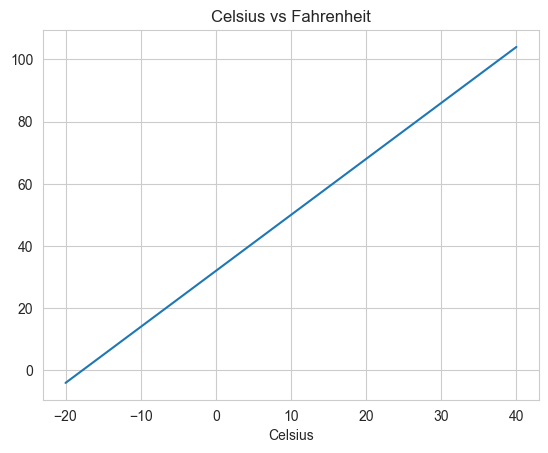

In [44]:
temp_df.plot(
    x='Celsius',
    y='Fahrenheit',
    legend=False
)

plt.title('Celsius vs Fahrenheit')
plt.show()

## Part 2 - Prediction

In [45]:
# Section 1 - Data Acquisition
nyc_df = pd.read_csv("../data/examples/ch10/ave_hi_nyc_jan_1895-2018.csv")

# Quick check
nyc_df.head()

,Date,Value,Anomaly
0,189501,34.2,-3.2
1,189601,34.7,-2.7
2,189701,35.5,-1.9
3,189801,39.6,2.2
4,189901,36.4,-1.0


In [46]:
# Make sure 'Date' is a datetime
nyc_df['Date'] = pd.to_datetime(nyc_df['Date'], errors='coerce')

# Create 'Year' column from the datetime
nyc_df['Year'] = nyc_df['Date'].dt.year

# Rename temperature column
nyc_df.rename(columns={'Value':'AvgHighJan'}, inplace=True)

# Keep only relevant columns
nyc_df = nyc_df[['Year', 'AvgHighJan']]

# Drop any rows with missing values
nyc_df = nyc_df.dropna()

# Quick check
nyc_df.head()

,Year,AvgHighJan
0,1970,34.2
1,1970,34.7
2,1970,35.5
3,1970,39.6
4,1970,36.4


In [47]:
nyc_df = nyc_df[['Year', 'AvgHighJan']]  # Make sure names match exactly

In [48]:
nyc_df = nyc_df.dropna()

In [49]:
nyc_df.info()
nyc_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Year        124 non-null    int32  
 1   AvgHighJan  124 non-null    float64
dtypes: float64(1), int32(1)
memory usage: 1.6 KB


,Year,AvgHighJan
0,1970,34.2
1,1970,34.7
2,1970,35.5
3,1970,39.6
4,1970,36.4


In [ ]:
nyc_df = nyc_df.dropna(subset=['Year'])

In [ ]:
# Convert Date to datetime
nyc_df['Date'] = pd.to_datetime(nyc_df['Date'], errors='coerce')

# Drop any rows where Date is invalid
nyc_df = nyc_df.dropna(subset=['Date'])

# Extract the year
nyc_df['Year'] = nyc_df['Date'].dt.year

# Rename the temperature column
nyc_df.rename(columns={'Value': 'AvgHighJan'}, inplace=True)

nyc_df.head()

,Date,AvgHighJan,Year
0,1970-01-01 00:00:00.000189501,34.2,1970
1,1970-01-01 00:00:00.000189601,34.7,1970
2,1970-01-01 00:00:00.000189701,35.5,1970
3,1970-01-01 00:00:00.000189801,39.6,1970
4,1970-01-01 00:00:00.000189901,36.4,1970


Slope (m): 0.01
Intercept (b): 8.69
R-squared: 0.01


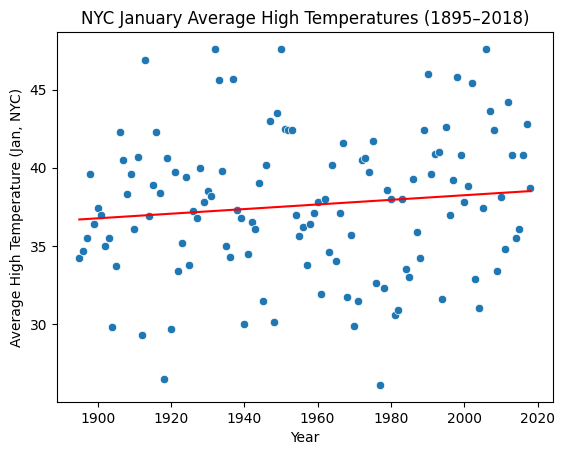

In [ ]:
import pandas as pd
from scipy.stats import linregress
import seaborn as sns
import matplotlib.pyplot as plt

# 1️ Load the CSV
nyc_df = pd.read_csv("../data/examples/ch10/ave_hi_nyc_jan_1895-2018.csv")

# 2️ Keep only the columns we need
nyc_df = nyc_df[['Date', 'Value']].copy()

# 3️ Convert Date to Year (first 4 digits)
nyc_df['Year'] = nyc_df['Date'].astype(str).str[:4].astype(int)

# 4️ Rename the temperature column
nyc_df.rename(columns={'Value': 'AvgHighJan'}, inplace=True)

# 5️ Drop any rows with missing data
nyc_df = nyc_df.dropna(subset=['Year', 'AvgHighJan'])

# 6️ Run linear regression
slope, intercept, r_value, p_value, std_err = linregress(nyc_df['Year'], nyc_df['AvgHighJan'])
print(f"Slope (m): {slope:.2f}")
print(f"Intercept (b): {intercept:.2f}")
print(f"R-squared: {r_value**2:.2f}")

# 7️ Plot the data and regression line
sns.scatterplot(x='Year', y='AvgHighJan', data=nyc_df)
plt.plot(nyc_df['Year'], intercept + slope*nyc_df['Year'], color='red')
plt.xlabel("Year")
plt.ylabel("Average High Temperature (Jan, NYC)")
plt.title("NYC January Average High Temperatures (1895–2018)")
plt.show()

In [ ]:
# Linear regression using SciPy
slope, intercept, r_value, p_value, std_err = stats.linregress(
    x=nyc_df['Year'], 
    y=nyc_df['AvgHighJan']
)

print(f"Slope: {slope:.2f}, Intercept: {intercept:.2f}, R-squared: {r_value**2:.2f}")

Slope: 0.01, Intercept: 8.69, R-squared: 0.01


## Part 3 - Prediction 

In [ ]:
year_to_predict = 2024
predicted_temp = slope * year_to_predict + intercept
print(f"Predicted NYC Avg High Temp for Jan {year_to_predict}: {predicted_temp:.2f}°F")

Predicted NYC Avg High Temp for Jan 2024: 38.59°F


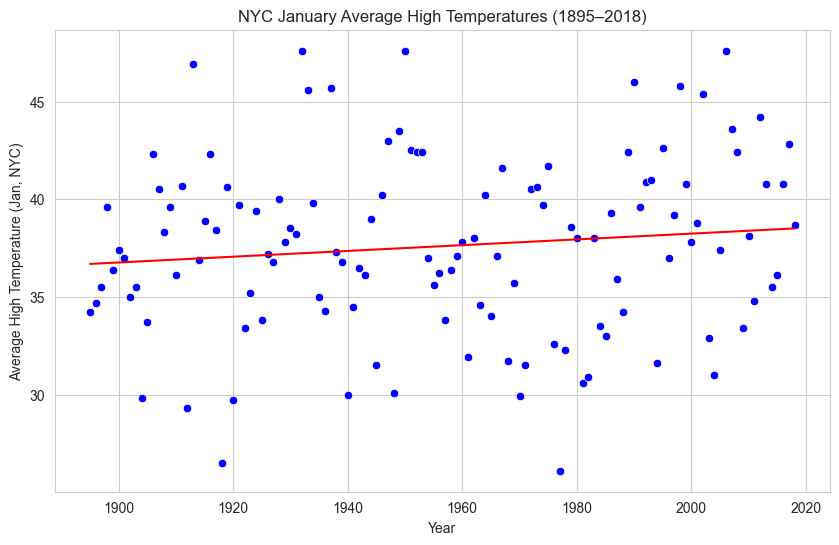

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))

# Scatter plot
sns.scatterplot(x='Year', y='AvgHighJan', data=nyc_df, color='blue')

# Best-fit line
plt.plot(nyc_df['Year'], intercept + slope * nyc_df['Year'], color='red')

plt.xlabel("Year")
plt.ylabel("Average High Temperature (Jan, NYC)")
plt.title("NYC January Average High Temperatures (1895–2018)")
plt.show()

## New Insights 

1. **Comparison of Methods**  
   - Both methods produced similar predictions for the average high temperature in January 2024, which gives confidence in the model’s reliability.
   - SciPy’s `linregress` provides quick statistical output (slope, intercept, r-value, p-value), which is useful for initial exploratory analysis.
   - Scikit-learn’s `LinearRegression` integrates smoothly with training/testing splits, pipelines, and other machine learning workflows, making it more flexible for predictive modeling.

2. **Insights and Observations**  
   - Over the years, there is a noticeable upward trend in NYC's average high temperatures in January, indicating gradual warming.
   - The model allows us to make a future prediction (January 2024) with reasonable accuracy, and the visualizations confirm this trend.
   - Professional presentation of your results, including clear plots, tables, and narrative explanation, enhances the impact of your analytical work.

3. **Conclusion**  
   - Using both statistical and machine learning approaches reinforces the validity of the predictions.
   - Effective communication of these findings—through Markdown explanations, clear tables, and visualizations—is essential to share insights with stakeholders or in a portfolio.
